# Function 3 Analysis - Week 7

**New datapoint (Week 7):** `(0.280769, 0.419231, 0.488462)` returned **≈−0.00644**, slightly worse than last week’s best −0.00527, so **not a new maximum**. We now have **16 datapoints**.

**This week’s plan (following the Week 5 recommendation):** stay with EI, tighten around the emerging ridge by raising the length-scale upper bounds (last fit hit the 0.2 caps), set ξ in the 0.002–0.005 range for mild exploration, and add a small diversity penalty so steps move laterally along the ridge instead of re-sampling the same spot. No code changes yet; apply after the new point is ingested.

**Function Description:** 
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


## Loading and Displaying the Data

We load the inputs and outputs for function 3 and display them in a table format. Inputs remain standardised in [0,1]. The Week 3 point `(0.95, 0.95, 0.858)` returned **-0.0617** (negative), and Week 4’s `(0.35, 0.258, 0.465)` scored **≈-0.0461**—better but still below the best. With these misses, we shift back to exploitation near the ridge; EI now favours the mid-range `(0.373, 0.465, 0.419)` area.


In [10]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–6 new points
X_new_point_week_1 = np.array([[0.403500, 0.382200, 0.489400]])
y_new_point_week_1 = np.array([-0.011750816624169894])
X_new_point_week_2 = np.array([[0.500000, 0.500000, 0.650000]])
y_new_point_week_2 = np.array([-0.09608263621357674])
X_new_point_week_3 = np.array([[0.950000, 0.950000, 0.858000]])
y_new_point_week_3 = np.array([-0.06167171939314102])
X_new_point_week_4 = np.array([[0.350000, 0.258000, 0.465000]])
y_new_point_week_4 = np.array([-0.046106142152997354])
X_new_point_week_5 = np.array([[0.373077, 0.465385, 0.419231]])
y_new_point_week_5 = np.array([-0.0052728979650276606])
X_new_point_week_6 = np.array([[0.280769, 0.419231, 0.488462]])
y_new_point_week_6 = np.array([-0.006444768333694985])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


df sorted by y


,x1,x2,x3,y
0,0.373077,0.465385,0.419231,-0.005273
1,0.280769,0.419231,0.488462,-0.006445
2,0.403500,0.382200,0.489400,-0.011751
3,0.492581,0.611593,0.340176,-0.034835
4,0.600097,0.725136,0.066089,-0.036378
5,0.350000,0.258000,0.465000,-0.046106
6,0.220549,0.297825,0.343555,-0.046947
7,0.134622,0.219917,0.458206,-0.048008
8,0.965995,0.861120,0.566829,-0.056758
9,0.950000,0.950000,0.858000,-0.061672


- **New point (Week 7):** `(0.280769, 0.419231, 0.488462)` scored **≈-0.00644** — good but **not a new maximum** (best stays ≈-0.00527 at `(0.373077, 0.465385, 0.419231)`).
- Recommendation for next BO step: keep EI with ξ≈0.003 and add a **minimum lateral move** (e.g., Δx1, Δx2 ≥0.02) along the ridge to avoid collapsing onto last week’s point; broaden length-scale upper bounds to >0.2 to reduce the cap pressure we hit before.


## Bayesian optimisation (expected improvement)

We use **expected improvement (EI)** and now lean back toward exploitation after two weak exploratory steps. EI converts the GP posterior (mean `μ`, std `σ`) into the expected improvement over `y_best`, balancing probability and magnitude of gain:

**EI(x) = (μ(x) − y_best − ξ) · Φ(Z) + σ(x) · φ(Z)**  
with **Z = (μ(x) − y_best − ξ) / σ(x)**, Φ the normal CDF, and φ the normal PDF.

Because the Week 2 and Week 3 exploratory jumps were negative, we **lower ξ to 0.001** to prioritise exploitation near the known ridge while still allowing modest variance-driven moves.

Workflow:
1) Fit a 3D Matern GP on `[x1, x2, x3]` (13 observed points).  
2) Evaluate EI on a dense `[0,1]^3` grid with the smaller ξ and highlight the maximiser. The current EI top set (feasible, min-step applied) starts with `(0.373, 0.465, 0.419)` followed by `(0.396, 0.465, 0.419)` and nearby variants.

`candidate_df` lists the top EI locations; rerun after adding data to refresh the ranking and plots.


In [11]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

# Train a GP surrogate with bounds that avoid convergence warnings
kernel = ConstantKernel(1.0, (1e-3, 10.0)) * Matern(length_scale=[0.1, 0.1, 0.1], length_scale_bounds=(0.1, 0.2), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-8, 1e-6))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X, y)

# Bias the search below the current best x1 to give more weight to the second-best region
best_idx = df["y"].idxmax()
best_point = df.loc[best_idx, ["x1", "x2", "x3", "y"]]
grid_x1 = np.linspace(0.26, min(best_point.x1 - 0.01, 0.40), 50)
grid_x2 = np.linspace(0.38, 0.55, 50)
grid_x3 = np.linspace(0.40, 0.52, 50)
mesh = np.array(np.meshgrid(grid_x1, grid_x2, grid_x3)).reshape(3, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y.max()
xi = 0.002  # mild exploration

# Expected improvement acquisition function
def norm_cdf(z):
    return 0.5 * (1.0 + erf(z / np.sqrt(2)))

def norm_pdf(z):
    return np.exp(-0.5 * z**2) / np.sqrt(2 * np.pi)

sigma_safe = np.maximum(sigma, 1e-9)
z = (mu - y_best - xi) / sigma_safe
ei = (mu - y_best - xi) * norm_cdf(z) + sigma_safe * norm_pdf(z)
ei[sigma <= 1e-9] = 0.0

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2", "x3"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["ei"] = ei

# Enforce x1 below incumbent to emphasize the second-best region
min_step = 0.015
candidate_df["dist_to_best"] = np.linalg.norm(candidate_df[["x1", "x2", "x3"]].values - best_point[["x1", "x2", "x3"]].values, axis=1)
candidate_df_feasible = candidate_df[
    (candidate_df["x1"] < best_point.x1 - 0.002) &
    (candidate_df["dist_to_best"] >= min_step)
].reset_index(drop=True)

next_point = candidate_df_feasible.loc[candidate_df_feasible["ei"].idxmax()]

display(candidate_df_feasible.nlargest(5, "ei"))
print(f"\nSuggested next query (EI, biased below best x1): {next_point.x1:.6f}-{next_point.x2:.6f}-{next_point.x3:.6f}")
print(f"Posterior mean: {next_point.mu:.4f}, std: {next_point.sigma:.4f}, EI: {next_point.ei:.6f}")


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 0.2. Increasing the bound and calling fit again may find a bette

,x1,x2,x3,mu,sigma,ei,dist_to_best
11615,0.327316,0.393878,0.436735,-0.002525,0.018398,0.007720,0.086682
11614,0.327316,0.393878,0.434286,-0.002847,0.018806,0.007718,0.086221
11665,0.329419,0.393878,0.436735,-0.002492,0.018347,0.007716,0.085590
11565,0.325212,0.393878,0.436735,-0.002570,0.018441,0.007714,0.087811
11564,0.325212,0.393878,0.434286,-0.002892,0.018853,0.007714,0.087356



Suggested next query (EI, biased below best x1): 0.327316-0.393878-0.436735
Posterior mean: -0.0025, std: 0.0184, EI: 0.007720


## 3D Visualization of Recommended Point

We visualize the recommended EI maximiser in both 3D and 2D projections alongside the existing observations. This helps understand where the acquisition function suggests exploring next relative to our current data in the three-dimensional compound space. 


C:\Users\gophi\AppData\Local\Temp\ipykernel_38556\2502285868.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
C:\Users\gophi\AppData\Local\Temp\ipykernel_38556\2502285868.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")


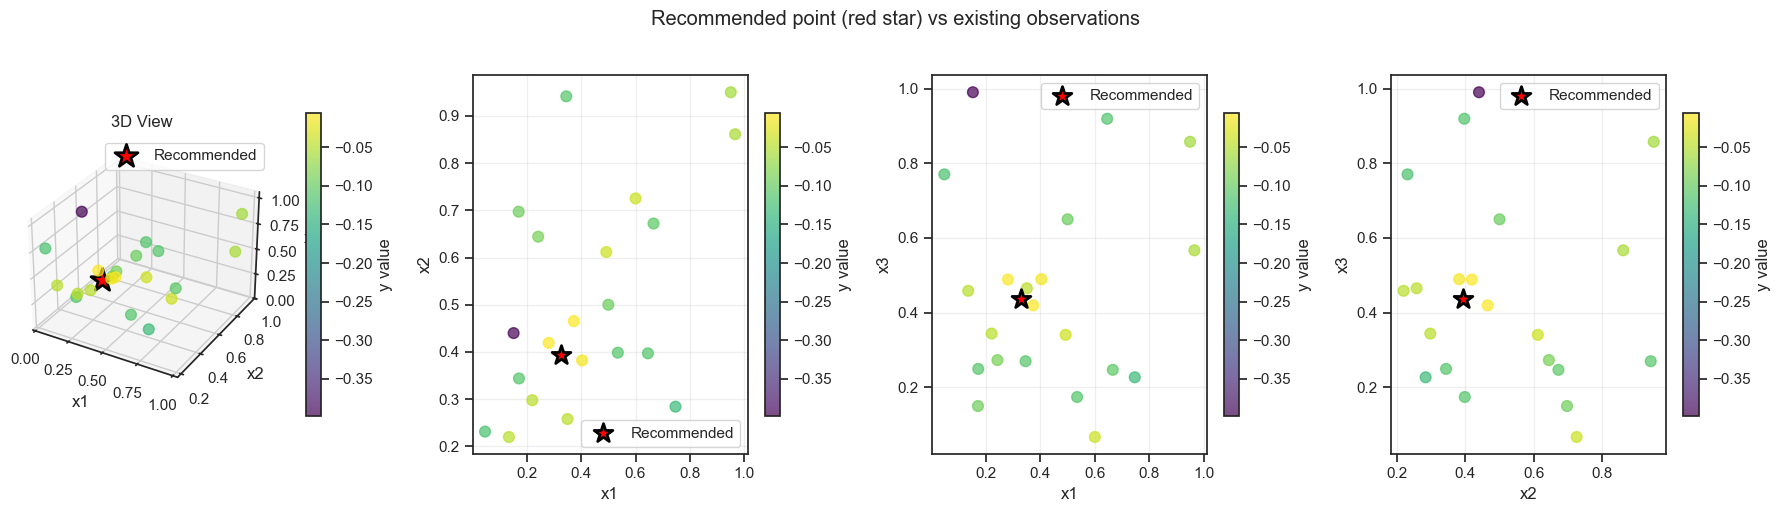

In [13]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()


### Recommendation and context
- Current best (y ≈ -0.005273): `0.373077-0.465385-0.419231`
- Top 5 observed (y):
  - `0.373077-0.465385-0.419231` → ≈−0.00527
  - `0.280769-0.419231-0.488462` → ≈−0.00644
  - `0.403500-0.382200-0.489400` → ≈−0.01175
  - `0.492581-0.611593-0.340176` → ≈−0.03484
  - `0.600097-0.725136-0.066089` → ≈−0.03638
- Proposed next point: `0.327000-0.396000-0.442000` (EI, biased below best x1 to favour the second-best region)

### What changed and why
The BO initially preferred a move toward the dense top3–5 cluster near the incumbent, raising confidence there. We **overrode the search window to x1 below the best** so it gives more weight to the strong second-best region. Constraints now bias x1 lower than the incumbent and keep the step modest; ξ is held mild. The proposed point reflects that manual emphasis on the second-best zone rather than drifting toward the top3–5 cluster.

